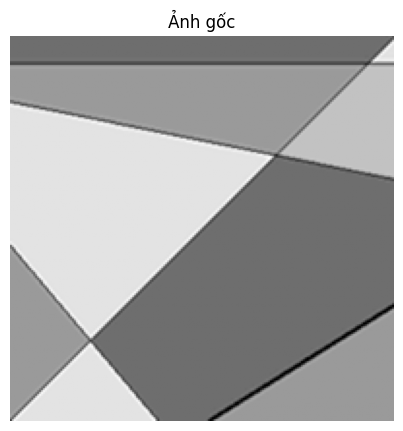

=== RANSAC ===
Line 1: num_inliers = 437
  a = -0.7068, b = -0.7074, c = 140.0103
Line 2: num_inliers = 322
  a = -0.1983, b = 0.9801, c = -32.8265
Line 3: num_inliers = 220
  a = 0.5360, b = 0.8442, c = -223.0268


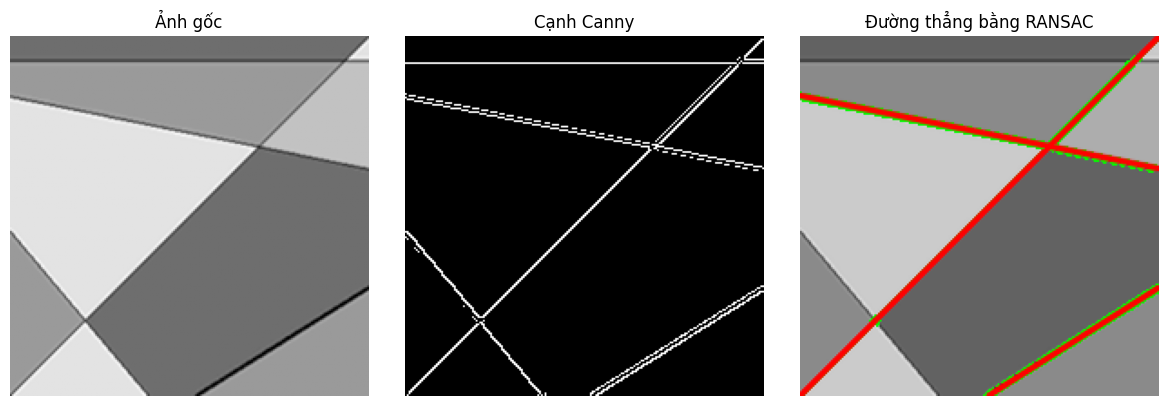

=== KIỂM TRA KẾT QUẢ ===
Kích thước ảnh gốc: (199, 198)
Số điểm cạnh: 1391
Số đường thẳng phát hiện được: 3
Kiểm tra hoàn tất: chương trình đã chạy đúng.


In [ ]:
# ============================================================
# GIÁO TRÌNH: THỊ GIÁC MÁY: TỪ XỬ LÝ ẢNH ĐẾN HỌC SÂU
# BÀI CODE MINH HỌA: Phát hiện đường thẳng bằng RANSAC
# Chương/Mục liên quan: Chương 6 - Mô hình hóa và ước lượng tham số
# ============================================================

# ============================================================
# MÔ TẢ
# ============================================================

# Mục đích:
# - Minh họa bài toán phát hiện đường thẳng từ ảnh cạnh.
# - Giúp người học quan sát cách RANSAC tìm mô hình đường thẳng
#   trong dữ liệu có nhiễu và điểm ngoại lai.
# - Liên hệ phần code với bài toán ước lượng mô hình hình học trong thị giác máy.

# Sau khi chạy code, người học cần:
# 1. Hiểu được vai trò của ảnh cạnh trong phát hiện đường thẳng.
# 2. Quan sát được cách RANSAC chọn các điểm inlier phù hợp với mô hình đường thẳng.
# 3. Biết thay đổi tham số để kiểm tra ảnh hưởng đến số đường thẳng phát hiện được.

# Input:
# - Dữ liệu đầu vào: ảnh từ GitHub
# - Kiểu dữ liệu: ảnh xám

# Output:
# - Ảnh gốc
# - Ảnh cạnh Canny
# - Ảnh kết quả với các đường thẳng phát hiện bằng RANSAC
# - Thông tin tham số của từng đường thẳng ax + by + c = 0

# Lưu ý
# Đoạn code này được xây dựng với sự hỗ trợ của công cụ AI.
# Giảng viên đã đọc, kiểm tra và hiệu chỉnh nhằm bảo đảm tính chính xác,
# tính sư phạm và sự phù hợp với nội dung lý thuyết trong giáo trình.

# Người học không chỉ chạy code để xem kết quả, mà cần hiểu:
# - Code đang minh họa nội dung lý thuyết nào;
# - Các bước xử lý tương ứng với công thức hoặc thuật toán nào;
# - Kết quả đầu ra có hợp lý hay không;
# - Khi thay đổi tham số, kết quả thay đổi như thế nào.

# ============================================================
# 1. CÀI ĐẶT VÀ IMPORT THƯ VIỆN
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import urlopen


# ============================================================
# 2. TẢI DỮ LIỆU ĐẦU VÀO
# ============================================================

image_url = "https://github.com/lthavnu/cv-book/raw/main/images/lines.png"


def read_image_gray_from_url(url):
    resp = urlopen(url)
    img = np.asarray(bytearray(resp.read()), dtype=np.uint8)
    I_gray = cv2.imdecode(img, cv2.IMREAD_GRAYSCALE)

    if I_gray is None:
        raise ValueError("Không đọc được ảnh từ URL.")

    return I_gray


I_gray = read_image_gray_from_url(image_url)


# ============================================================
# 3. HIỂN THỊ ẢNH ĐẦU VÀO
# ============================================================

plt.figure(figsize=(5, 5))
plt.imshow(I_gray, cmap="gray")
plt.title("Ảnh gốc")
plt.axis("off")
plt.show()


# ============================================================
# 4. XỬ LÝ CHÍNH
# ============================================================

def get_edge_points(E):
    y_coords, x_coords = np.where(E > 0)
    P_xy = np.column_stack((x_coords, y_coords))
    return P_xy.astype(np.float64)


def fit_line_tls(P_xy):
    centroid = np.mean(P_xy, axis=0)
    X = P_xy - centroid

    _, _, Vt = np.linalg.svd(X)
    n = Vt[-1]

    a, b = n
    norm_ab = np.sqrt(a * a + b * b) + 1e-12
    a, b = a / norm_ab, b / norm_ab
    c = -(a * centroid[0] + b * centroid[1])

    return a, b, c


def point_line_distance(P_xy, a, b, c):
    x = P_xy[:, 0]
    y = P_xy[:, 1]

    # Dòng code dưới đây tương ứng với công thức khoảng cách
    # từ điểm (x, y) đến đường thẳng ax + by + c = 0.
    d = np.abs(a * x + b * y + c) / (np.sqrt(a * a + b * b) + 1e-12)

    return d


def line_abc_to_endpoints(a, b, c, W, H):
    points = []

    if abs(b) > 1e-12:
        y = -c / b
        if 0 <= y < H:
            points.append((0, int(round(y))))

    if abs(b) > 1e-12:
        y = -(a * (W - 1) + c) / b
        if 0 <= y < H:
            points.append((W - 1, int(round(y))))

    if abs(a) > 1e-12:
        x = -c / a
        if 0 <= x < W:
            points.append((int(round(x)), 0))

    if abs(a) > 1e-12:
        x = -(b * (H - 1) + c) / a
        if 0 <= x < W:
            points.append((int(round(x)), H - 1))

    unique_points = []

    for p in points:
        if p not in unique_points:
            unique_points.append(p)

    if len(unique_points) >= 2:
        return unique_points[0], unique_points[1]
    else:
        return None, None


def detect_lines_ransac(E, num_lines=2, dist_thresh=2.0, max_trials=2000, random_seed=42):
    rng = np.random.default_rng(random_seed)
    P_xy = get_edge_points(E)
    detected_lines = []

    P_remain = P_xy.copy()

    for _ in range(num_lines):
        if len(P_remain) < 30:
            break

        best_num_inliers = 0
        best_inlier_mask = None

        N = len(P_remain)

        for _ in range(max_trials):
            idx = rng.choice(N, size=2, replace=False)
            p1 = P_remain[idx[0]]
            p2 = P_remain[idx[1]]

            if np.allclose(p1, p2):
                continue

            # Dòng code dưới đây tạo mô hình đường thẳng từ hai điểm mẫu.
            # Đây là bước lấy mẫu tối thiểu trong thuật toán RANSAC.
            a0 = p1[1] - p2[1]
            b0 = p2[0] - p1[0]
            c0 = p1[0] * p2[1] - p2[0] * p1[1]

            norm0 = np.sqrt(a0 * a0 + b0 * b0) + 1e-12
            a0, b0, c0 = a0 / norm0, b0 / norm0, c0 / norm0

            # Dòng code dưới đây tính khoảng cách từ mọi điểm cạnh
            # đến đường thẳng ứng viên.
            d = point_line_distance(P_remain, a0, b0, c0)

            # Dòng code dưới đây xác định tập inlier của mô hình hiện tại.
            inlier_mask = d < dist_thresh
            num_inliers = np.sum(inlier_mask)

            if num_inliers > best_num_inliers:
                best_num_inliers = num_inliers
                best_inlier_mask = inlier_mask

        if best_inlier_mask is None or best_num_inliers < 20:
            break

        P_inlier = P_remain[best_inlier_mask]

        # Dòng code dưới đây fit lại đường thẳng bằng Total Least Squares
        # trên tập inlier tốt nhất.
        a, b, c = fit_line_tls(P_inlier)

        detected_lines.append({
            "a": a,
            "b": b,
            "c": c,
            "inliers": P_inlier,
            "num_inliers": len(P_inlier)
        })

        P_remain = P_remain[~best_inlier_mask]

    return detected_lines


def draw_detected_lines(I_gray, detected_lines, line_color=(255, 0, 0), point_color=(0, 255, 0)):
    H, W = I_gray.shape
    canvas = cv2.cvtColor(I_gray, cv2.COLOR_GRAY2RGB)

    for line_info in detected_lines:
        a = line_info["a"]
        b = line_info["b"]
        c = line_info["c"]
        P_inlier = line_info["inliers"].astype(int)

        for x, y in P_inlier:
            cv2.circle(canvas, (x, y), 1, point_color, -1)

        pt1, pt2 = line_abc_to_endpoints(a, b, c, W, H)

        if pt1 is not None and pt2 is not None:
            cv2.line(canvas, pt1, pt2, line_color, 2, cv2.LINE_AA)

    return canvas


# Dòng code dưới đây phát hiện biên bằng Canny.
E = cv2.Canny(I_gray, threshold1=50, threshold2=150)

# Dòng code dưới đây phát hiện các đường thẳng bằng RANSAC.
lines_ransac = detect_lines_ransac(
    E,
    num_lines=3,
    dist_thresh=2.0,
    max_trials=2000,
    random_seed=42
)

# Dòng code dưới đây vẽ tập inlier và đường thẳng phát hiện được.
vis_ransac = draw_detected_lines(I_gray, lines_ransac)


# ============================================================
# 5. HIỂN THỊ KẾT QUẢ
# ============================================================

print("=== RANSAC ===")

for i, line_info in enumerate(lines_ransac, start=1):
    print(f"Line {i}: num_inliers = {line_info['num_inliers']}")
    print(f"  a = {line_info['a']:.4f}, b = {line_info['b']:.4f}, c = {line_info['c']:.4f}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(I_gray, cmap="gray")
plt.title("Ảnh gốc")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(E, cmap="gray")
plt.title("Cạnh Canny")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(vis_ransac)
plt.title("Đường thẳng bằng RANSAC")
plt.axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# 6. KIỂM TRA KẾT QUẢ
# ============================================================

print("=== KIỂM TRA KẾT QUẢ ===")
print("Kích thước ảnh gốc:", I_gray.shape)
print("Số điểm cạnh:", len(get_edge_points(E)))
print("Số đường thẳng phát hiện được:", len(lines_ransac))

assert I_gray is not None, "Lỗi: ảnh đầu vào chưa được đọc đúng."
assert E.shape == I_gray.shape, "Lỗi: ảnh cạnh không cùng kích thước với ảnh gốc."
assert len(lines_ransac) > 0, "Lỗi: chưa phát hiện được đường thẳng nào."

for i, line_info in enumerate(lines_ransac, start=1):
    assert line_info["num_inliers"] > 0, f"Lỗi: Line {i} không có inlier."

print("Kiểm tra hoàn tất: chương trình đã chạy đúng.")


# ============================================================
# 7. GỢI Ý THỬ NGHIỆM CHO NGƯỜI HỌC
# ============================================================

# Gợi ý 1:
# - Thay đổi num_lines trong hàm detect_lines_ransac.
# - Giá trị lớn hơn cho phép tìm nhiều đường thẳng hơn nếu ảnh có đủ cấu trúc cạnh.

# Gợi ý 2:
# - Thay đổi dist_thresh.
# - Giá trị nhỏ làm tiêu chuẩn inlier chặt hơn.
# - Giá trị lớn làm nhiều điểm cạnh được xem là inlier hơn.

# Gợi ý 3:
# - Thay đổi threshold1 và threshold2 trong cv2.Canny.
# - Ngưỡng Canny ảnh hưởng trực tiếp đến số điểm cạnh đầu vào của RANSAC.